# Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Loading Data

In [2]:
df=pd.read_csv("loan_approval_data.csv")
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# Handling Missing Value


In [4]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["float64"]).columns

In [5]:
from sklearn.impute import SimpleImputer#Simple imputer helps to fill the null value by mean,median,mode

#Null numerical values filling with mean
num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

#Null categorical value filling with mode
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

# EDA -exploratory data analysis

In [8]:
#EDA ---------------------------------------------------------------

#How balanced are classes are?

# class_val_count=df["Loan_Approved"].value_counts()
# plt.pie(class_val_count,labels=["No","Yes"],autopct="%1.1f%%")
# plt.title("Is loan approved or not?")

#Analyze categories

#Gender
# gender_count=df["Gender"].value_counts()
# ax=sns.barplot(gender_count)
# ax.bar_label(ax.containers[0])

#Employment_Status
# status=df["Employment_Status"].value_counts()
# ax=sns.barplot(status)
# ax.bar_label(ax.containers[0])

#Loan_Purpose
# purpose=df["Loan_Purpose"].value_counts()
# ax=sns.barplot(purpose)
# ax.bar_label(ax.containers[0])
# plt.tight_layout()

#Education_Level
# Education=df["Education_Level"].value_counts()
# ax=sns.barplot(Education)
# ax.bar_label(ax.containers[0])
# plt.tight_layout()

#Employer_Category
# Employer=df["Employer_Category"].value_counts()
# ax=sns.barplot(Employer)
# ax.bar_label(ax.containers[0])
# plt.tight_layout()

#Property_Area
# Property_Area=df["Property_Area"].value_counts()
# ax=sns.barplot(Property_Area)
# ax.bar_label(ax.containers[0])
# plt.tight_layout()

#Loan_Purpose
# Loan_Purpose=df["Loan_Purpose"].value_counts()
# ax=sns.barplot(Loan_Purpose)
# ax.bar_label(ax.containers[0])
# plt.tight_layout()

#Analyse Income
# sns.histplot(
#     data=df,
#     x="Applicant_Income",
#     bins=20
# )
# sns.histplot(
#     data=df,
#     x="Coapplicant_Income",
#     bins=20
# )


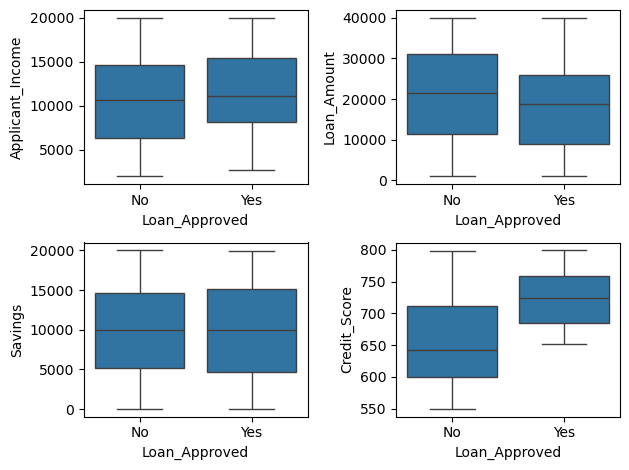

In [9]:
#Outliers - box plots

# sns.boxplot(
#     data=df,
#     x="Loan_Approved",
#     y="Applicant_Income"
# )
# sns.boxplot(
#     data=df,
#     x="Loan_Approved",
#     y="Coapplicant_Income"
 #  )
# sns.boxplot(
#     data=df,
#     x="Loan_Approved",
#     y="Savings"
# )
# sns.boxplot(
#     data=df,
#     x="Loan_Approved",
#     y="Loan_Amount"
# )

fig,axes=plt.subplots(2,2)

sns.boxplot(ax=axes[0,0],
            data=df,
            x="Loan_Approved",
            y="Applicant_Income"
           )
sns.boxplot(ax=axes[0,1],
            data=df,
            x="Loan_Approved",
            y="Loan_Amount"
           )
sns.boxplot(ax=axes[1,0],
            data=df,
            x="Loan_Approved",
            y="Savings"
           )
sns.boxplot(ax=axes[1,1],
            data=df,
            x="Loan_Approved",
            y="Credit_Score"
           )

plt.tight_layout()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

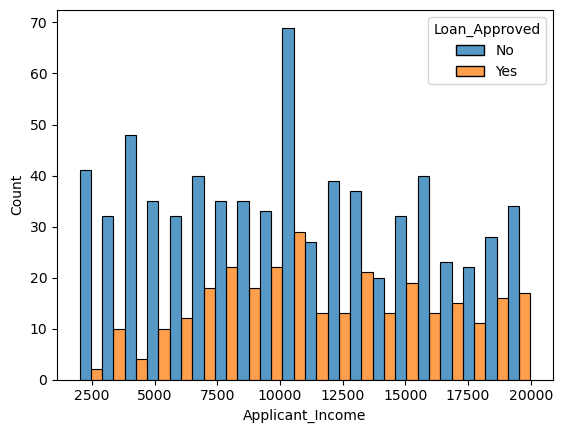

In [10]:
#Credit Score with Loan Approval

# sns.histplot(
#     data=df,
#     x="Credit_Score",
#     hue="Loan_Approved",
#     bins=50,
#     multiple="dodge"
# )
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [11]:
df=df.drop("Applicant_ID",axis=1)

# Encoding

In [ ]:
df.sample(10)
df.info()

In [14]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

#Changing Categorical variable into int or float

#Label Encoding----sklearn LabelEncoder

le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

#One Hot Encoding---sklearn one hot encoder

col=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

enc = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

encoded=enc.fit_transform(df[col])

encoded_df=pd.DataFrame(encoded, columns=enc.get_feature_names_out(col), index=df.index)

df = pd.concat([df.drop(columns=col), encoded_df], axis=1)

In [28]:
enc.get_feature_names_out(col)
encoded
encoded_df
col

['Employment_Status',
 'Marital_Status',
 'Loan_Purpose',
 'Property_Area',
 'Gender',
 'Employer_Category']

# Correlation Heatmap

In [15]:
df["Education_Level"]
df["Loan_Approved"]

0      0
1      0
2      1
3      0
4      1
      ..
995    0
996    0
997    0
998    1
999    0
Name: Loan_Approved, Length: 1000, dtype: int64

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

In [ ]:
df.corr(numeric_only=True)["Loan_Approved"].sort_values(ascending=False)

# Train-test-split +Feature Scaling

In [ ]:
X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [ ]:
df["Loan_Approved"]==0

### Train-Test-Split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
#X_train
#y_train
X_test
#y_test

### Scaling Data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
X_train_scaled
X_test_scaled

# Train & Evaluate Models

#### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

logi_model=LogisticRegression(max_iter=10000)
logi_model.fit(X_train_scaled,y_train)

In [ ]:
y_pred=logi_model.predict(X_test_scaled)

In [ ]:
# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: \n", confusion_matrix(y_test, y_pred))

#### KNN -- K Nearest Neighbors

In [ ]:
from  sklearn.neighbors import KNeighborsClassifier

knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)

y_pred=knn_model.predict(X_test_scaled)
y_pred

In [ ]:
# Evaluation
print("KNN Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: \n", confusion_matrix(y_test, y_pred))

#### Naive_Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb_model=GaussianNB()
gnb_model.fit(X_train_scaled,y_train)

y_pred=gnb_model.predict(X_test_scaled)
y_pred

In [ ]:
# Evaluation
print("GaussianNB Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: \n", confusion_matrix(y_test, y_pred))

# Best Model on the basis of Precision => Naive Bayes

## Feature Engineering

In [ ]:
# Add or Tranform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
df

In [ ]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

In [ ]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

In [ ]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))